# Central Preprocessing: Regression, Classification, Clustering CSVs

This notebook cleans the raw laptop dataset once and produces exactly
three files, one per track:

| File | Target column | Notes |
|---|---|---|
| `regression.csv` | `price` (continuous) | full dataset, cleaned + encoded |
| `classification.csv` | `price_category` (4 classes) | `price` excluded from features |
| `clustering.csv` | none | unsupervised, no target column at all |


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
os.makedirs("data", exist_ok=True)

df_raw = pd.read_csv("laptop_price_uncleaned.csv")
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (1303, 12)


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## Cleaning

Column names, missing values (justified per column), numeric parsing,
duplicate removal, categorical standardization, and outlier capping.

Duplicates removed: 29


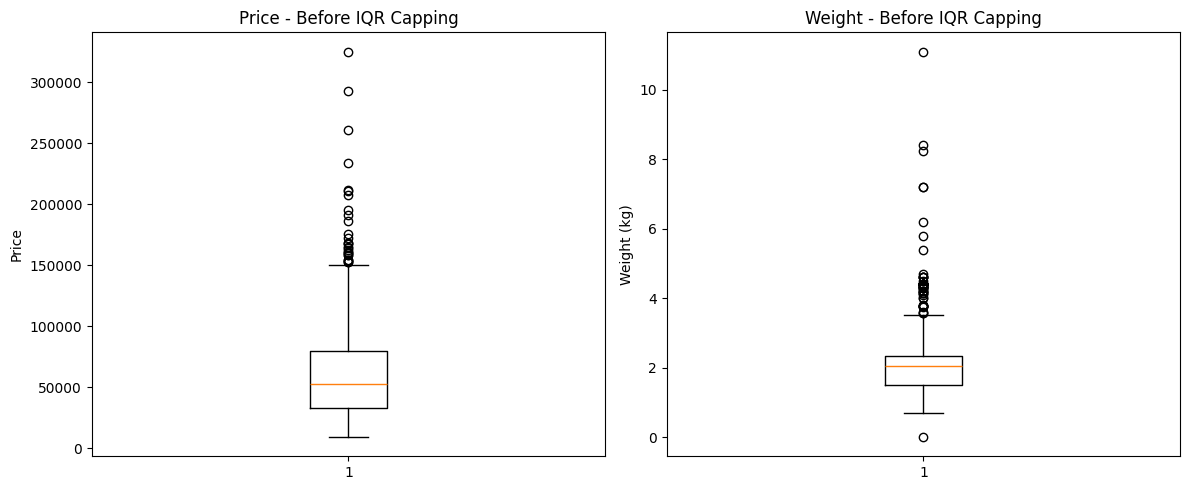

Missing values remaining: 0
Shape after cleaning: (1243, 11)


In [4]:
df = df_raw.copy()

df.columns = (
    df.columns.str.strip().str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^0-9a-z_]", "", regex=True)
)
if "unnamed_0" in df.columns:
    df = df.drop(columns=["unnamed_0"])

def parse_ram(v):
    if pd.isnull(v):
        return np.nan
    digits = "".join(ch for ch in str(v) if ch.isdigit())
    return float(digits) if digits else np.nan

def parse_weight(v):
    if pd.isnull(v):
        return np.nan
    v = str(v).lower().replace("kg", "").strip()
    try:
        return float(v)
    except ValueError:
        return np.nan

def parse_inches(v):
    if pd.isnull(v):
        return np.nan
    v = str(v).replace('"', "").strip()
    try:
        return float(v)
    except ValueError:
        return np.nan

df["ram"] = df["ram"].apply(parse_ram)
df["weight"] = df["weight"].apply(parse_weight)
df["inches"] = df["inches"].apply(parse_inches)
for col in ["price", "ram", "weight", "inches"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Missing values: categorical -> "Unknown", weight -> median,
# price/ram/inches missing -> row dropped (core specs, can't be guessed)
for col in ["gpu", "opsys"]:
    df[col] = df[col].fillna("Unknown")
df["weight"] = df["weight"].fillna(df["weight"].median())
df = df.dropna(subset=["price", "ram", "inches"]).reset_index(drop=True)

# Duplicates
dup_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {dup_count}")

# Categorical standardization
df["company"] = df["company"].str.strip().str.title()
df["opsys"] = df["opsys"].str.strip().str.title()
df["typename"] = df["typename"].str.strip()

# Outlier capping (IQR rule) on price and weight; capped, not deleted,
# since a genuinely high-end laptop is a valid observation
def iqr_cap(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s.clip(lower, upper)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df["price"].dropna())
axes[0].set_title("Price - Before IQR Capping")
axes[0].set_ylabel("Price")

axes[1].boxplot(df["weight"].dropna())
axes[1].set_title("Weight - Before IQR Capping")
axes[1].set_ylabel("Weight (kg)")

plt.tight_layout()
plt.show()

for col in ["price", "weight"]:
    df[col] = iqr_cap(df[col])

print("Missing values remaining:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

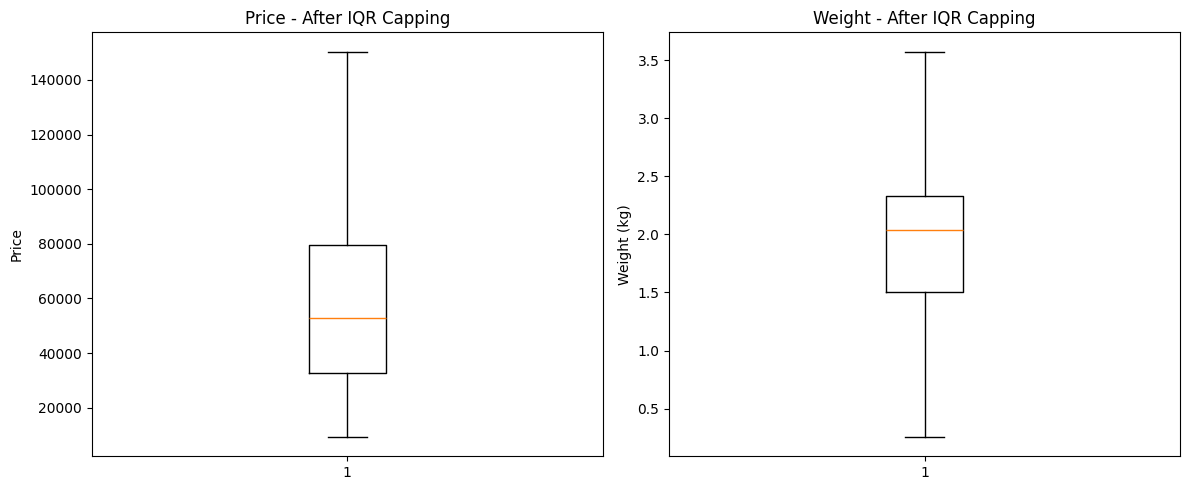

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df["price"].dropna())
axes[0].set_title("Price - After IQR Capping")
axes[0].set_ylabel("Price")

axes[1].boxplot(df["weight"].dropna())
axes[1].set_title("Weight - After IQR Capping")
axes[1].set_ylabel("Weight (kg)")

plt.tight_layout()
plt.show()

## Feature Engineering

`storage_gb` and `has_ssd`/`has_hdd` are extracted from the combined
`memory` text since raw storage information is unusable as-is.
`ppi` (pixels per inch) is computed from resolution and screen size,
since sharpness is a more direct price-relevant signal than resolution
or screen size alone.

In [ ]:
df["is_ips"] = df["screenresolution"].str.contains("IPS", case=False, na=False)
df["is_touchscreen"] = df["screenresolution"].str.contains("Touchscreen", case=False, na=False)

res = df["screenresolution"].str.extract(r"(\d+)x(\d+)")
df["res_width"] = pd.to_numeric(res[0], errors="coerce")
df["res_height"] = pd.to_numeric(res[1], errors="coerce")

def total_storage_gb(text):
    if pd.isnull(text):
        return np.nan
    text = str(text).upper()
    total = 0.0
    for part in text.split("+"):
        part = part.strip()
        tb = pd.Series(part).str.extract(r"([\d\.]+)\s*TB")[0][0]
        gb = pd.Series(part).str.extract(r"([\d\.]+)\s*GB")[0][0]
        if pd.notnull(tb):
            total += float(tb) * 1024
        elif pd.notnull(gb):
            total += float(gb)
    return total if total > 0 else np.nan

df["storage_gb"] = df["memory"].apply(total_storage_gb)
df["has_ssd"] = df["memory"].str.contains("SSD", case=False, na=False)
df["has_hdd"] = df["memory"].str.contains("HDD", case=False, na=False)
df["storage_gb"] = df["storage_gb"].fillna(df["storage_gb"].median())

df = df.dropna(subset=["res_width", "res_height"]).reset_index(drop=True)
df["ppi"] = np.sqrt(df["res_width"]**2 + df["res_height"]**2) / df["inches"]

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (1243, 19)


## Categorical Encoding

`company`, `typename`, and `opsys` are one-hot encoded here since
encoding does not carry the same train/test leakage risk that scaling
does (it is not a fitted statistic like a mean or variance). `cpu` and
`gpu` are dropped from the modeling columns; their free-text
cardinality is too high for one-hot encoding without further parsing
that was not identified as necessary for this dataset.

In [ ]:
model_categorical = ["company", "typename", "opsys"]
model_numeric = ["ram", "weight", "inches", "storage_gb", "res_width", "res_height", "ppi"]
model_boolean = ["is_ips", "is_touchscreen", "has_ssd", "has_hdd"]

df_encoded = pd.get_dummies(df, columns=model_categorical, drop_first=True)
for col in model_boolean:
    df_encoded[col] = df_encoded[col].astype(int)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (1243, 47)


,inches,screenresolution,cpu,ram,memory,gpu,weight,price,is_ips,is_touchscreen,...,typename_Ultrabook,typename_Workstation,opsys_Chrome Os,opsys_Linux,opsys_Mac Os X,opsys_Macos,opsys_No Os,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7
0,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128GB SSD,Intel Iris Plus Graphics 640,1.37,71378.6832,1,0,...,True,False,False,False,False,True,False,False,False,False
1,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128GB Flash Storage,Intel HD Graphics 6000,1.34,47895.5232,0,0,...,True,False,False,False,False,True,False,False,False,False
2,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,1.86,30636.0000,0,0,...,False,False,False,False,False,False,True,False,False,False
3,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512GB SSD,AMD Radeon Pro 455,1.83,135195.3360,1,0,...,True,False,False,False,False,True,False,False,False,False
4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256GB SSD,Intel Iris Plus Graphics 650,1.37,96095.8080,1,0,...,True,False,False,False,False,True,False,False,False,False


## Build and Save the Three Track Files

* **`regression.csv`**: all engineered/encoded features plus `price`.
* **`classification.csv`**: same features plus `price_category`
  (quartile bins of `price`); `price` itself is dropped since it would
  trivially leak the label.
* **`clustering.csv`**: same features, no target column at all.

In [ ]:
encoded_feature_cols = [c for c in df_encoded.columns
                        if c not in ["price", "cpu", "gpu", "screenresolution", "memory"]]

# --- Regression ---
regression_df = df_encoded[encoded_feature_cols + ["price"]]
regression_df.to_csv("data/regression.csv", index=False)
print("regression.csv shape:", regression_df.shape)

regression.csv shape: (1243, 43)


In [ ]:
# --- Classification ---
price_labels = ["Budget", "Mid-range", "Premium", "Flagship"]
price_category = pd.qcut(df_encoded["price"], q=4, labels=price_labels)

classification_df = df_encoded[encoded_feature_cols].copy()
classification_df["price_category"] = price_category
classification_df.to_csv("data/classification.csv", index=False)
print("classification.csv shape:", classification_df.shape)
print(classification_df["price_category"].value_counts())

classification.csv shape: (1243, 43)
price_category
Mid-range    312
Budget       311
Flagship     311
Premium      309
Name: count, dtype: int64


In [ ]:
# --- Clustering (unsupervised: no target column) ---
clustering_df = df_encoded[encoded_feature_cols]
clustering_df.to_csv("data/clustering.csv", index=False)
print("clustering.csv shape:", clustering_df.shape)

clustering.csv shape: (1243, 42)


In [ ]:
print("Files in data/:")
for f in sorted(os.listdir("data")):
    if f.startswith(("regression", "classification", "clustering")):
        path = os.path.join("data", f)
        print(f"  {f:25s} {os.path.getsize(path)/1024:8.1f} KB")

Files in data/:
  classification.csv           301.9 KB
  clustering.csv               291.6 KB
  regression.csv               303.0 KB
